# Predicción del rendimiento agrícola

## Carga del dataset

In [1]:
import json
from pathlib import Path
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import RFE
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

SEMILLA = 42
np.random.seed(SEMILLA)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
warnings.filterwarnings("ignore", category=FutureWarning)

DATASET_URL = "https://www.kaggle.com/api/v1/datasets/download/miadul/smart-crop-yield-predication-dataset"
ARCHIVO_LOCAL = Path("crop_yield_dataset.csv")

try:
    df = pd.read_csv(
        DATASET_URL,
        compression="zip",
        keep_default_na=False,
        na_values=[""]
    )
    origen_carga = "API pública de Kaggle"
except Exception as error_remoto:
    df = pd.read_csv(
        ARCHIVO_LOCAL,
        keep_default_na=False,
        na_values=[""]
    )
    origen_carga = f"archivo local ({type(error_remoto).__name__})"

# En el CSV, None significa ausencia de riego o cultivo previo; no es un nulo.
df["Irrigation"] = df["Irrigation"].replace({"None": "Sin_irrigacion"})
df["Previous_Crop"] = df["Previous_Crop"].replace({"None": "Sin_cultivo_previo"})

print("Origen utilizado:", origen_carga)
df.head()

Origen utilizado: API pública de Kaggle


,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop,Yield_ton_per_ha
0,Maize,Region_C,Sandy,7.01,1485.4,19.7,40.3,105.1,Drip,10.2,23.2,Rice,101.48
1,Barley,Region_D,Loam,5.79,399.4,29.1,55.4,221.8,Sprinkler,35.5,7.4,Barley,127.39
2,Rice,Region_C,Clay,7.24,980.9,30.5,74.4,61.2,Sprinkler,40.0,5.1,Wheat,68.99
3,Maize,Region_D,Loam,6.79,1054.3,26.4,62.0,257.8,Drip,42.7,23.7,Sin_cultivo_previo,169.06
4,Maize,Region_D,Sandy,5.96,744.6,20.4,70.9,195.8,Drip,25.5,15.6,Maize,118.71


In [2]:
print("Dimensiones originales del dataset:", df.shape)
print("Registros originales:", df.shape[0])
print("Columnas originales:", df.shape[1])
print("Variables independientes:", df.shape[1] - 1)
print("Variable dependiente: Yield_ton_per_ha")

Dimensiones originales del dataset: (10000, 13)
Registros originales: 10000
Columnas originales: 13
Variables independientes: 12
Variable dependiente: Yield_ton_per_ha


## Calidad de los datos

### Registros duplicados y valores nulos

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.isnull().sum()

Crop                  0
Region                0
Soil_Type             0
Soil_pH               0
Rainfall_mm           0
Temperature_C         0
Humidity_pct          0
Fertilizer_Used_kg    0
Irrigation            0
Pesticides_Used_kg    0
Planting_Density      0
Previous_Crop         0
Yield_ton_per_ha      0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Crop                10000 non-null  object 
 1   Region              10000 non-null  object 
 2   Soil_Type           10000 non-null  object 
 3   Soil_pH             10000 non-null  float64
 4   Rainfall_mm         10000 non-null  float64
 5   Temperature_C       10000 non-null  float64
 6   Humidity_pct        10000 non-null  float64
 7   Fertilizer_Used_kg  10000 non-null  float64
 8   Irrigation          10000 non-null  object 
 9   Pesticides_Used_kg  10000 non-null  float64
 10  Planting_Density    10000 non-null  float64
 11  Previous_Crop       10000 non-null  object 
 12  Yield_ton_per_ha    10000 non-null  float64
dtypes: float64(8), object(5)
memory usage: 1015.8+ KB


In [6]:
df.dtypes

Crop                   object
Region                 object
Soil_Type              object
Soil_pH               float64
Rainfall_mm           float64
Temperature_C         float64
Humidity_pct          float64
Fertilizer_Used_kg    float64
Irrigation             object
Pesticides_Used_kg    float64
Planting_Density      float64
Previous_Crop          object
Yield_ton_per_ha      float64
dtype: object

No se encontraron duplicados ni valores nulos reales. Las cinco variables `object` son nominales y las ocho variables `float64` representan mediciones continuas. La configuración de lectura evita convertir la categoría literal `None` en `NaN`.

### Valores atípicos

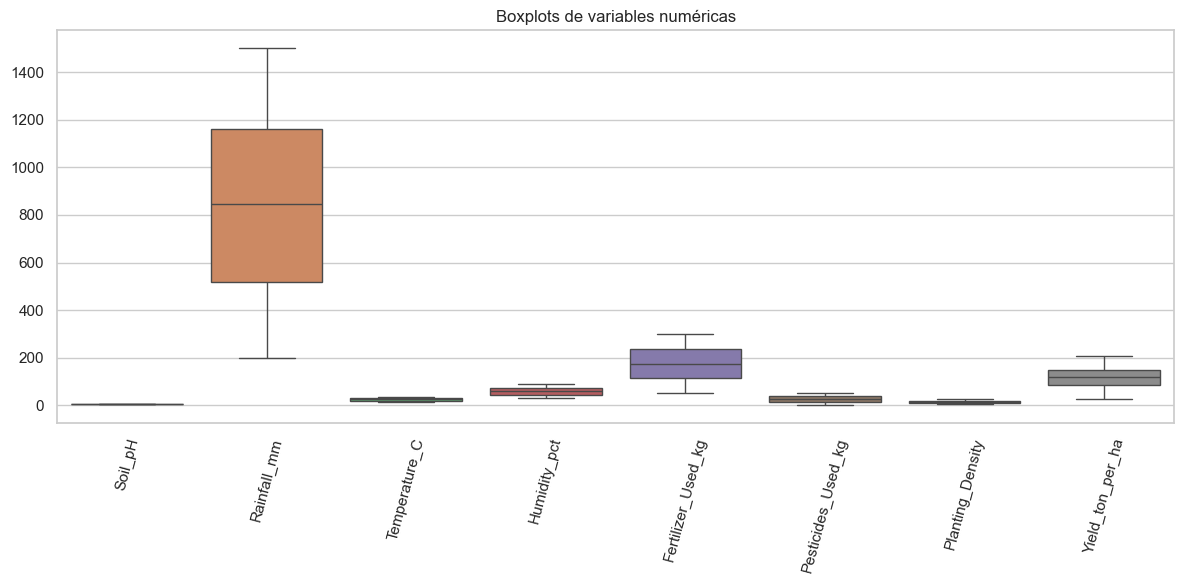

,Outliers IQR
Soil_pH,0
Rainfall_mm,0
Temperature_C,0
Humidity_pct,0
Fertilizer_Used_kg,0
Pesticides_Used_kg,0
Planting_Density,0
Yield_ton_per_ha,0


In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include="number"))
plt.xticks(rotation=75)
plt.title("Boxplots de variables numéricas")
plt.tight_layout()
plt.show()

numericas_calidad = df.select_dtypes(include="number")
q1 = numericas_calidad.quantile(0.25)
q3 = numericas_calidad.quantile(0.75)
iqr = q3 - q1
outliers = ((numericas_calidad < q1 - 1.5 * iqr) | (numericas_calidad > q3 + 1.5 * iqr)).sum()
outliers.to_frame("Outliers IQR")

El criterio IQR no identifica valores atípicos. No se eliminan registros porque no existe evidencia de error y una eliminación injustificada podría sesgar el modelo.

### Variabilidad e identificadores

In [8]:
df.nunique(dropna=False)

Crop                     4
Region                   4
Soil_Type                3
Soil_pH                201
Rainfall_mm           6964
Temperature_C          201
Humidity_pct           601
Fertilizer_Used_kg    2450
Irrigation               4
Pesticides_Used_kg     501
Planting_Density       201
Previous_Crop            5
Yield_ton_per_ha      7209
dtype: int64

In [9]:
df.select_dtypes(include="number").var().sort_values()

Soil_pH                    0.330350
Temperature_C             33.531406
Planting_Density          34.024899
Pesticides_Used_kg       206.022472
Humidity_pct             299.881862
Yield_ton_per_ha        1441.923214
Fertilizer_Used_kg      5178.839824
Rainfall_mm           139629.837091
dtype: float64

In [10]:
df.columns

Index(['Crop', 'Region', 'Soil_Type', 'Soil_pH', 'Rainfall_mm',
       'Temperature_C', 'Humidity_pct', 'Fertilizer_Used_kg', 'Irrigation',
       'Pesticides_Used_kg', 'Planting_Density', 'Previous_Crop',
       'Yield_ton_per_ha'],
      dtype='object')

No existen columnas constantes ni identificadores. Todas las columnas independientes describen el cultivo, el suelo, el clima o el manejo agrícola.

### Correlación inicial

In [11]:
correlacion_inicial = df.corr(numeric_only=True)
display(correlacion_inicial.round(4))
display(
    correlacion_inicial["Yield_ton_per_ha"]
    .drop("Yield_ton_per_ha")
    .sort_values(key=abs, ascending=False)
    .to_frame("Correlación con y")
)

,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Pesticides_Used_kg,Planting_Density,Yield_ton_per_ha
Soil_pH,1.0000,-0.0131,-0.0152,-0.0098,0.0027,0.0056,-0.0117,-0.0025
Rainfall_mm,-0.0131,1.0000,0.0092,0.0015,-0.0007,0.0135,0.0019,0.2942
Temperature_C,-0.0152,0.0092,1.0000,-0.0115,0.0008,-0.0011,0.0139,0.0359
Humidity_pct,-0.0098,0.0015,-0.0115,1.0000,0.0051,-0.0167,-0.0088,0.0071
Fertilizer_Used_kg,0.0027,-0.0007,0.0008,0.0051,1.0000,-0.0065,-0.0005,0.9458
Pesticides_Used_kg,0.0056,0.0135,-0.0011,-0.0167,-0.0065,1.0000,-0.0024,-0.0034
Planting_Density,-0.0117,0.0019,0.0139,-0.0088,-0.0005,-0.0024,1.0000,0.0005
Yield_ton_per_ha,-0.0025,0.2942,0.0359,0.0071,0.9458,-0.0034,0.0005,1.0000


,Correlación con y
Fertilizer_Used_kg,0.945808
Rainfall_mm,0.294182
Temperature_C,0.035878
Humidity_pct,0.007116
Pesticides_Used_kg,-0.003400
Soil_pH,-0.002520
Planting_Density,0.000458


## Análisis exploratorio de datos

### Estadísticas descriptivas

In [12]:
display(df.describe().T.round(4))

,count,mean,std,min,25%,50%,75%,max
Soil_pH,10000.0,6.5167,0.5748,5.50,6.020,6.520,7.0100,7.50
Rainfall_mm,10000.0,843.6647,373.6708,200.00,518.000,845.300,1161.8500,1499.70
Temperature_C,10000.0,24.9758,5.7906,15.00,20.000,24.900,30.1000,35.00
Humidity_pct,10000.0,60.0526,17.3171,30.00,45.100,60.200,75.1000,90.00
Fertilizer_Used_kg,10000.0,175.0833,71.9642,50.00,113.300,175.000,237.9000,300.00
Pesticides_Used_kg,10000.0,25.0555,14.3535,0.00,12.600,25.300,37.5000,50.00
Planting_Density,10000.0,14.9979,5.8331,5.00,9.900,15.000,20.1000,25.00
Yield_ton_per_ha,10000.0,117.8911,37.9727,28.45,87.135,117.705,149.1475,207.21


In [13]:
display(df.median(numeric_only=True).to_frame("Mediana").round(4))

,Mediana
Soil_pH,6.520
Rainfall_mm,845.300
Temperature_C,24.900
Humidity_pct,60.200
Fertilizer_Used_kg,175.000
Pesticides_Used_kg,25.300
Planting_Density,15.000
Yield_ton_per_ha,117.705


In [14]:
display(
    df.quantile(
        [0.10, 0.25, 0.50, 0.75, 0.90, 0.95],
        numeric_only=True
    ).T.round(4)
)

,0.10,0.25,0.50,0.75,0.90,0.95
Soil_pH,5.710,6.020,6.520,7.0100,7.310,7.410
Rainfall_mm,331.490,518.000,845.300,1161.8500,1366.210,1431.605
Temperature_C,17.000,20.000,24.900,30.1000,33.000,34.000
Humidity_pct,35.900,45.100,60.200,75.1000,83.900,86.900
Fertilizer_Used_kg,74.900,113.300,175.000,237.9000,274.000,286.805
Pesticides_Used_kg,5.200,12.600,25.300,37.5000,44.800,47.300
Planting_Density,6.900,9.900,15.000,20.1000,23.000,24.000
Yield_ton_per_ha,66.558,87.135,117.705,149.1475,168.462,177.340


### Distribución de la variable dependiente

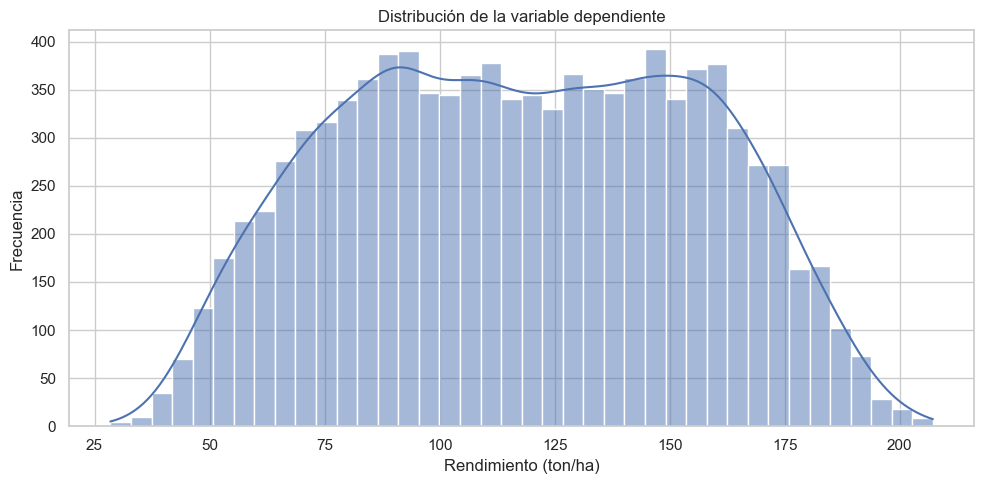

Media: 117.891
Mediana: 117.705
Asimetría: -0.008


In [15]:
target = "Yield_ton_per_ha"

sns.histplot(df[target], bins=40, kde=True)
plt.title("Distribución de la variable dependiente")
plt.xlabel("Rendimiento (ton/ha)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("Media:", round(df[target].mean(), 3))
print("Mediana:", round(df[target].median(), 3))
print("Asimetría:", round(df[target].skew(), 3))

`Yield_ton_per_ha` es continua, se expresa en toneladas por hectárea y tiene variación suficiente para una tarea de regresión. La media y la mediana son próximas, por lo que no se transforma la variable objetivo.

### Visualización de las variables

In [16]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

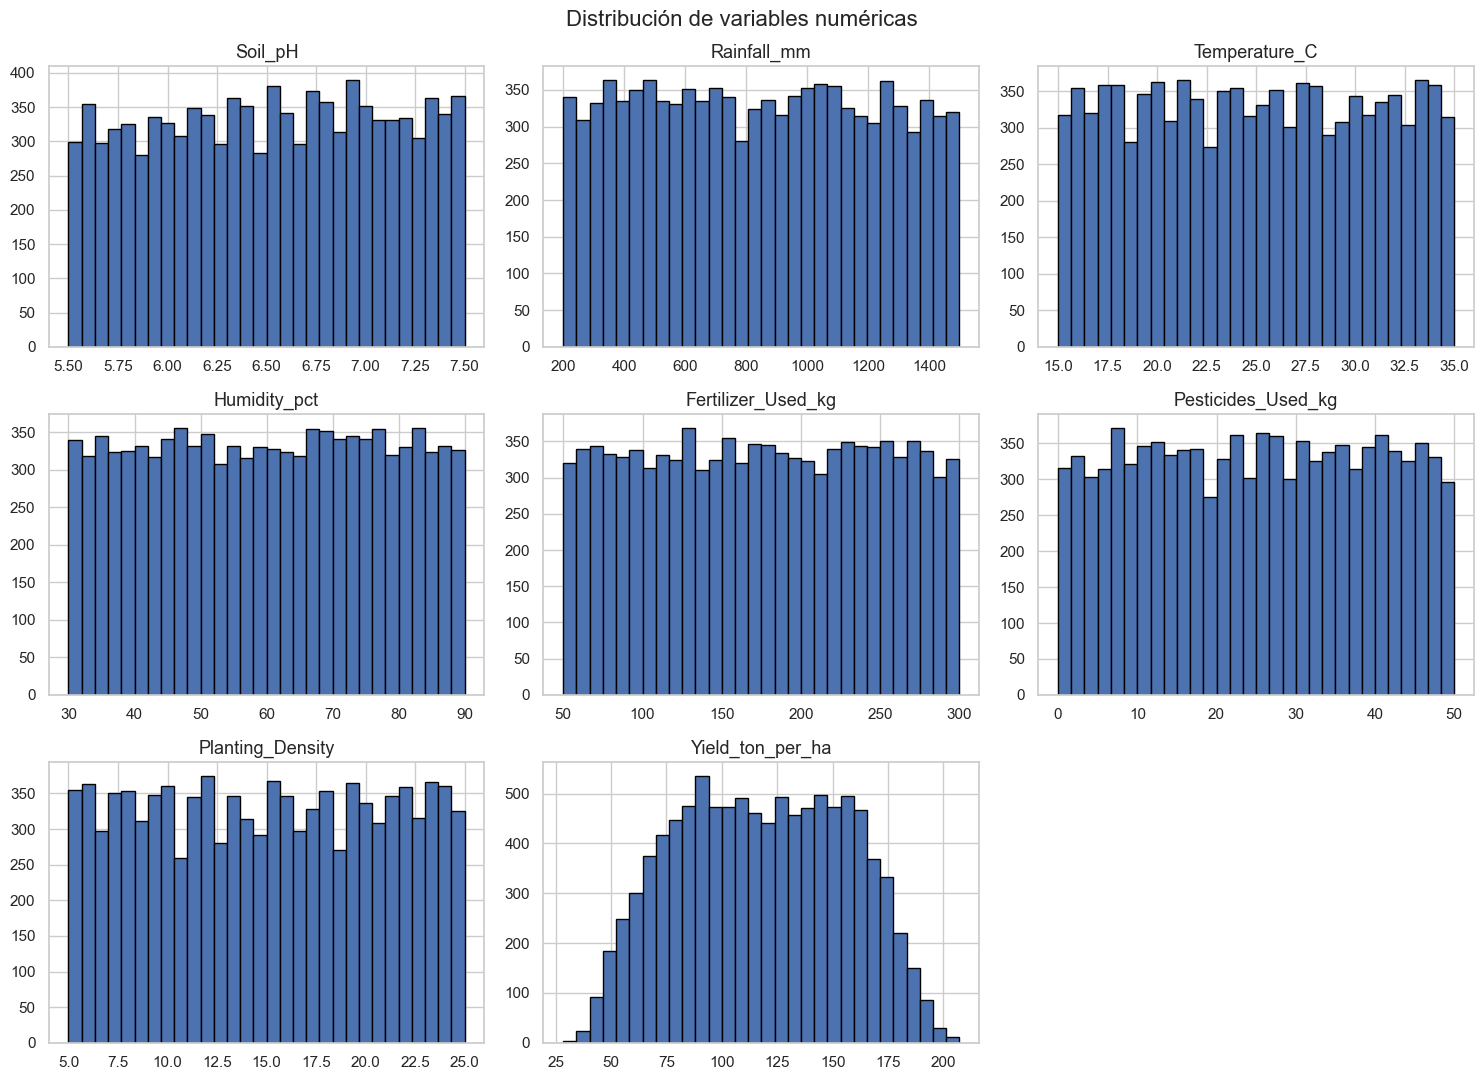

In [17]:
df.hist(bins=30, figsize=(15, 11), color="#4C72B0", edgecolor="black")
plt.suptitle("Distribución de variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

Las variables numéricas presentan escalas distintas; lluvia y fertilizante abarcan rangos mucho mayores que pH o temperatura. Esto se considerará al aplicar StandardScaler dentro de los pipelines.

## Boxplots

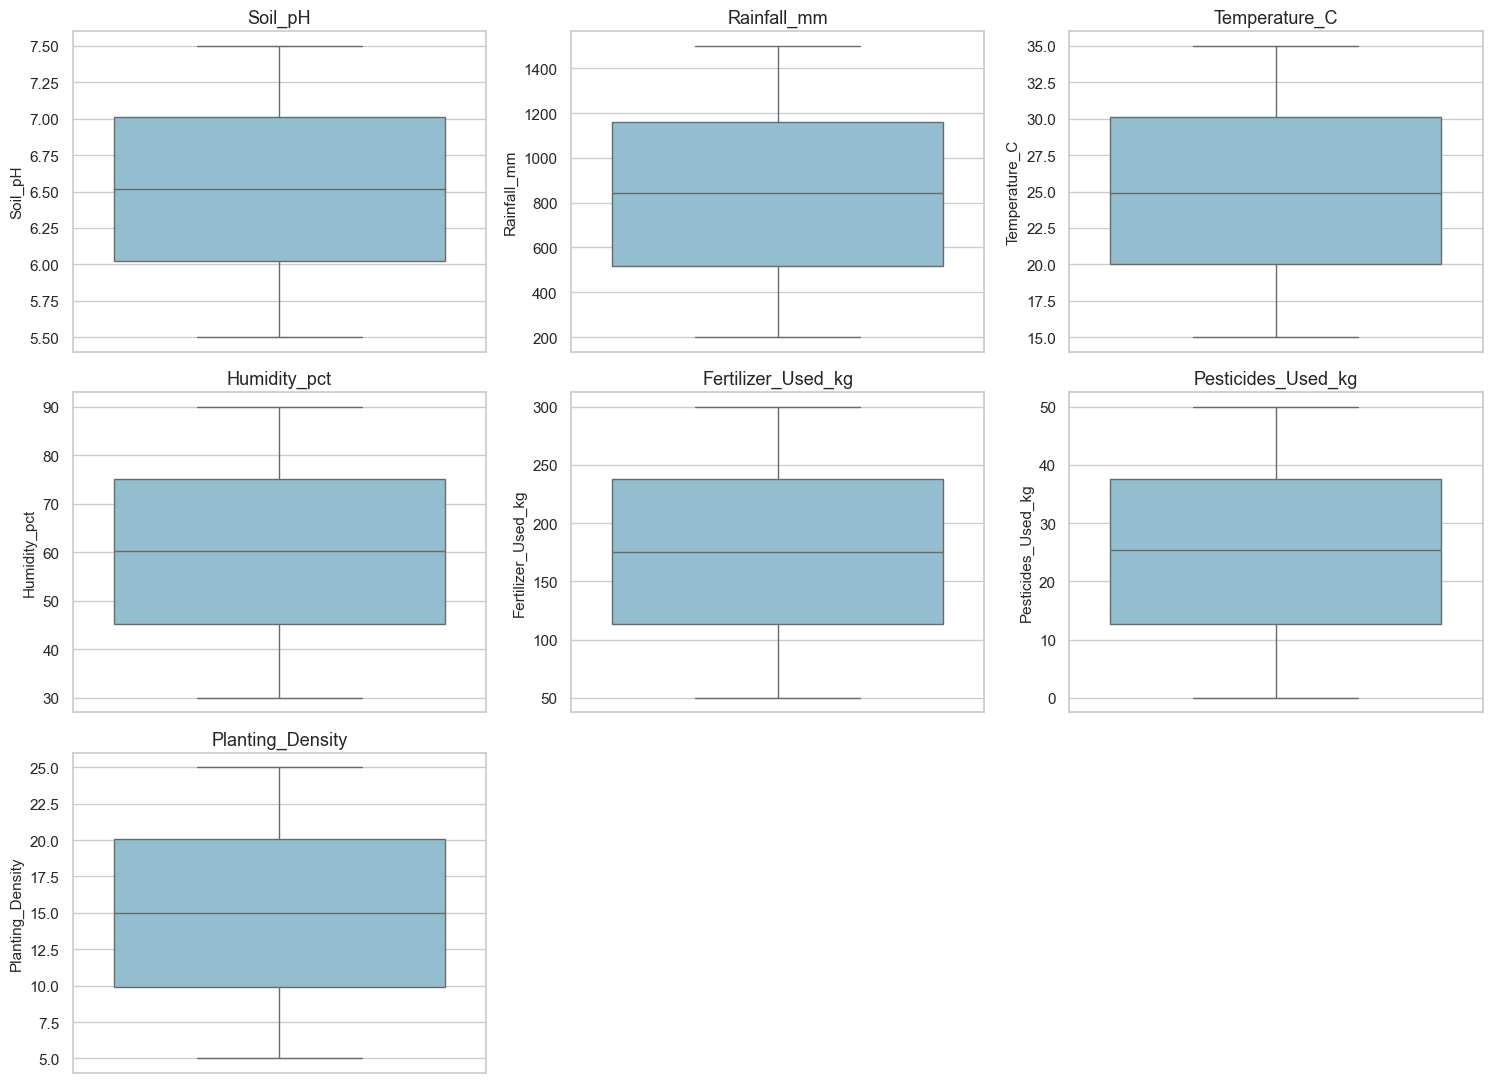

In [18]:
columnas_numericas_eda = [
    col for col in df.select_dtypes(include="number").columns if col != target
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.ravel()
for eje, columna in zip(axes, columnas_numericas_eda):
    sns.boxplot(y=df[columna], ax=eje, color="#89C2D9")
    eje.set_title(columna)
for eje in axes[len(columnas_numericas_eda):]:
    eje.remove()
plt.tight_layout()
plt.show()

## Gráficas de barras

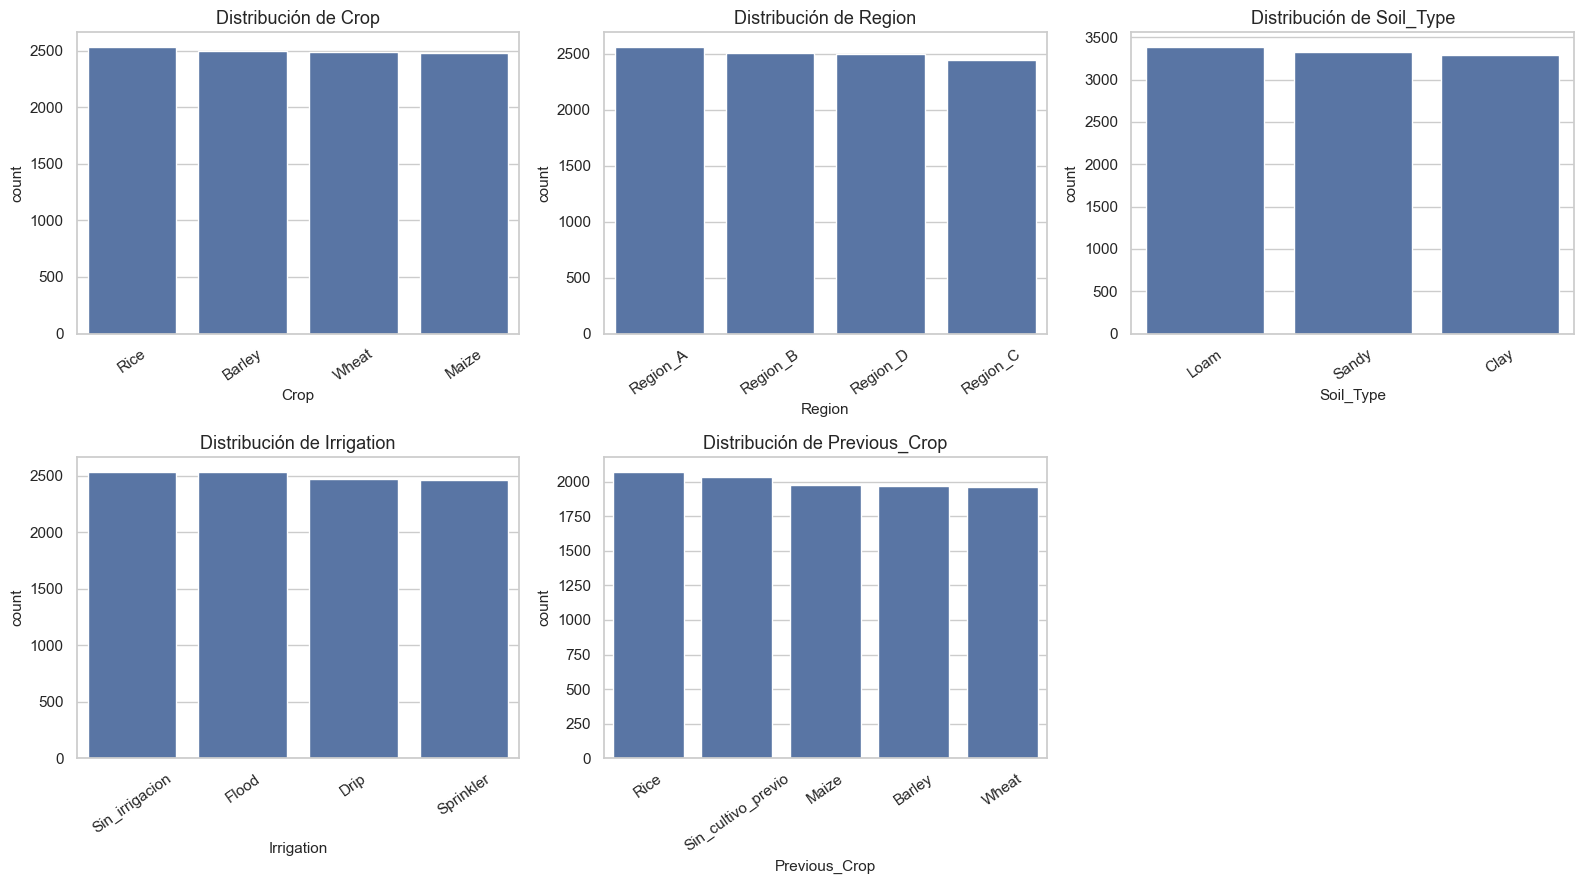

In [19]:
columnas_categoricas_eda = df.select_dtypes(include="object").columns.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for eje, columna in zip(axes, columnas_categoricas_eda):
    orden = df[columna].value_counts().index
    sns.countplot(data=df, x=columna, order=orden, ax=eje, color="#4C72B0")
    eje.set_title(f"Distribución de {columna}")
    eje.tick_params(axis="x", rotation=35)
for eje in axes[len(columnas_categoricas_eda):]:
    eje.remove()
plt.tight_layout()
plt.show()

In [20]:
medias_categoricas = pd.concat([
    df.groupby(col, as_index=False)[target].mean()
      .rename(columns={col: "Categoría", target: "Rendimiento medio"})
      .assign(Variable=col)
    for col in columnas_categoricas_eda
], ignore_index=True)

display(
    medias_categoricas[
        ["Variable", "Categoría", "Rendimiento medio"]
    ].round(4)
)

,Variable,Categoría,Rendimiento medio
0,Crop,Barley,117.6375
1,Crop,Maize,118.1113
2,Crop,Rice,117.1850
3,Crop,Wheat,118.6471
4,Region,Region_A,117.2759
5,Region,Region_B,117.0658
6,Region,Region_C,118.4072
7,Region,Region_D,118.8452
8,Soil_Type,Clay,117.2957
9,Soil_Type,Loam,117.9020


### Relaciones entre variables

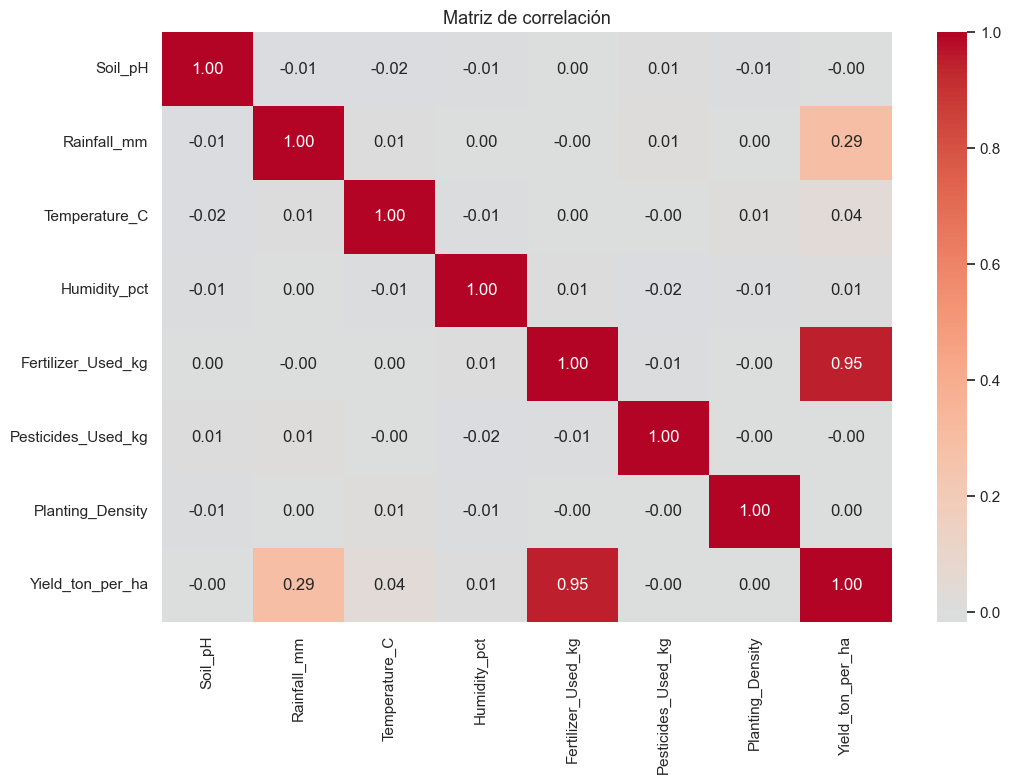

In [21]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".2f", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

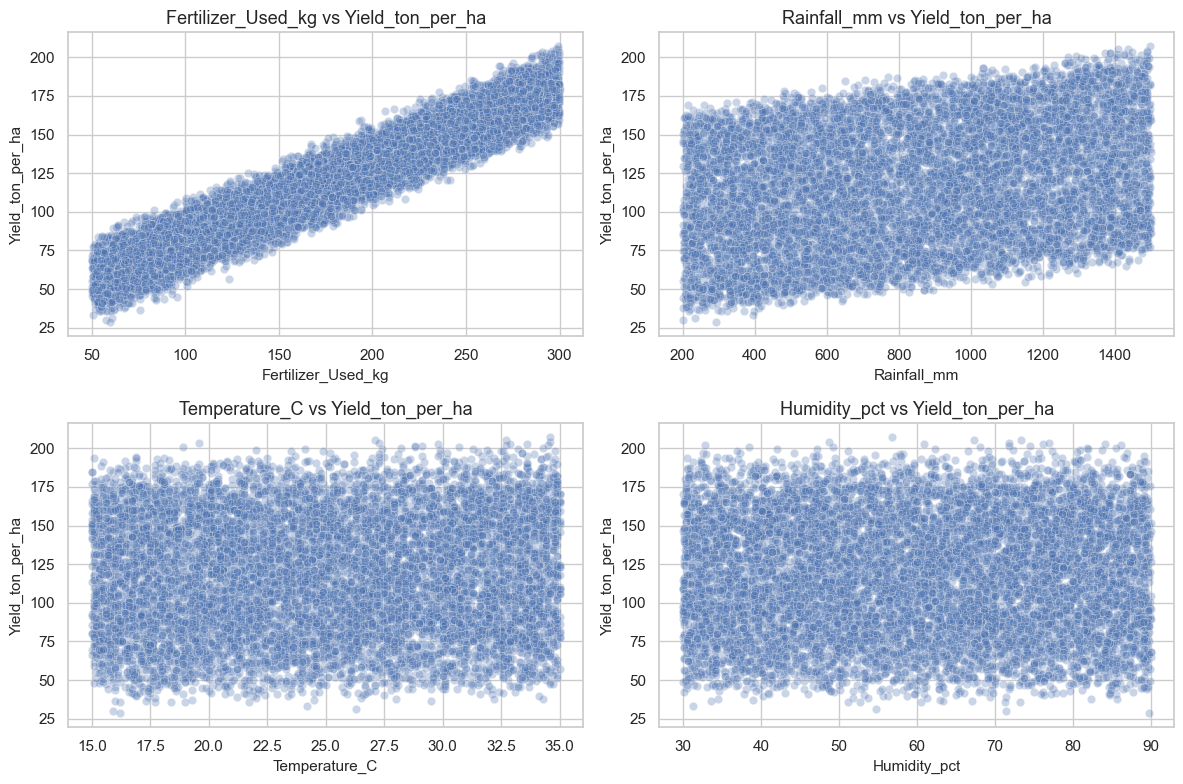

In [22]:
corr_target = corr_matrix[target].abs().sort_values(ascending=False)
top_features = corr_target.index[1:5]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
for eje, columna in zip(axes, top_features):
    sns.scatterplot(data=df, x=columna, y=target, alpha=0.3, ax=eje)
    eje.set_title(f"{columna} vs {target}")
plt.tight_layout()
plt.show()

La relación lineal principal corresponde a `Fertilizer_Used_kg`, seguida por `Rainfall_mm`. Las diferencias entre medias categóricas son menores; por ello la selección no se basará solo en correlación y también utilizará RFE e importancia de árboles.

## Preparación de los datos

### Definición de X e y

In [23]:
target = "Yield_ton_per_ha"
df_clean = df.copy()

In [24]:
X = df_clean.drop(columns=[target]).copy()
y = df_clean[target].copy()

print(f"Variables predictoras: {X.shape[1]}")
print(f"Variable dependiente: {target}")

Variables predictoras: 12
Variable dependiente: Yield_ton_per_ha


### Vista de los datos preparados

In [25]:
X.head()

,Crop,Region,Soil_Type,Soil_pH,Rainfall_mm,Temperature_C,Humidity_pct,Fertilizer_Used_kg,Irrigation,Pesticides_Used_kg,Planting_Density,Previous_Crop
0,Maize,Region_C,Sandy,7.01,1485.4,19.7,40.3,105.1,Drip,10.2,23.2,Rice
1,Barley,Region_D,Loam,5.79,399.4,29.1,55.4,221.8,Sprinkler,35.5,7.4,Barley
2,Rice,Region_C,Clay,7.24,980.9,30.5,74.4,61.2,Sprinkler,40.0,5.1,Wheat
3,Maize,Region_D,Loam,6.79,1054.3,26.4,62.0,257.8,Drip,42.7,23.7,Sin_cultivo_previo
4,Maize,Region_D,Sandy,5.96,744.6,20.4,70.9,195.8,Drip,25.5,15.6,Maize


In [26]:
y.head()

0    101.48
1    127.39
2     68.99
3    169.06
4    118.71
Name: Yield_ton_per_ha, dtype: float64

### Tratamiento de valores faltantes

In [27]:
df_clean.isnull().sum()

Crop                  0
Region                0
Soil_Type             0
Soil_pH               0
Rainfall_mm           0
Temperature_C         0
Humidity_pct          0
Fertilizer_Used_kg    0
Irrigation            0
Pesticides_Used_kg    0
Planting_Density      0
Previous_Crop         0
Yield_ton_per_ha      0
dtype: int64

In [28]:
# El dataset no tiene nulos reales; se introduce 5% de forma reproducible en X.
rng = np.random.default_rng(SEMILLA)
n_missing = round(0.05 * len(X))

for columna in ["Rainfall_mm", "Soil_Type"]:
    indices = rng.choice(X.index, size=n_missing, replace=False)
    X.loc[indices, columna] = np.nan

# Se protege 20% antes de selección, PCA y validación cruzada.
X_desarrollo, X_prueba_final, y_desarrollo, y_prueba_final = train_test_split(
    X, y, test_size=0.20, random_state=SEMILLA
)

In [29]:
missing_summary = pd.DataFrame({
    "Nulos": X.isnull().sum(),
    "Porcentaje": X.isnull().mean().mul(100).round(2)
})
missing_summary[missing_summary["Nulos"] > 0]

,Nulos,Porcentaje
Soil_Type,500,5.0
Rainfall_mm,500,5.0


Se generó 5% de nulos en `Rainfall_mm` y `Soil_Type`, únicamente en variables independientes y con semilla fija. La lluvia se imputará con mediana y el suelo con moda. La prueba final queda protegida y no participa en selección ni validación cruzada.

In [30]:
# Vista de imputación ajustada solo con el conjunto de desarrollo.
X_imputed = X_desarrollo.copy()
imputador_lluvia = SimpleImputer(strategy="median")
imputador_suelo = SimpleImputer(strategy="most_frequent")
X_imputed[["Rainfall_mm"]] = imputador_lluvia.fit_transform(X_desarrollo[["Rainfall_mm"]])
X_imputed[["Soil_Type"]] = imputador_suelo.fit_transform(X_desarrollo[["Soil_Type"]])

print("Mediana de lluvia:", round(float(imputador_lluvia.statistics_[0]), 3))
print("Moda de suelo:", imputador_suelo.statistics_[0])

Mediana de lluvia: 850.55
Moda de suelo: Loam


In [31]:
X_imputed.isnull().sum().to_frame("Nulos después de imputar")

,Nulos después de imputar
Crop,0
Region,0
Soil_Type,0
Soil_pH,0
Rainfall_mm,0
Temperature_C,0
Humidity_pct,0
Fertilizer_Used_kg,0
Irrigation,0
Pesticides_Used_kg,0


### Tipos de datos resultantes

In [32]:
X.dtypes

Crop                   object
Region                 object
Soil_Type              object
Soil_pH               float64
Rainfall_mm           float64
Temperature_C         float64
Humidity_pct          float64
Fertilizer_Used_kg    float64
Irrigation             object
Pesticides_Used_kg    float64
Planting_Density      float64
Previous_Crop          object
dtype: object

### Conversión de variables categóricas

Las cinco variables categóricas son nominales. OneHotEncoder produciría 20 indicadores y ampliaría el dataset de 12 a 27 columnas. Para conservar una sola columna por atributo se utiliza `OrdinalEncoder` con un orden explícito y artificial:

- `Crop`: Barley, Maize, Rice, Wheat.
- `Region`: Region_A, Region_B, Region_C, Region_D.
- `Soil_Type`: Clay, Loam, Sandy.
- `Irrigation`: Sin_irrigacion, Drip, Sprinkler, Flood.
- `Previous_Crop`: Sin_cultivo_previo, Barley, Maize, Rice, Wheat.

Los códigos no representan superioridad ni distancia agronómica. Esta compactación puede afectar modelos lineales, PCA y cortes de árboles; su efecto se comprobará con validación cruzada.

### Escalado

Se utilizará `StandardScaler` porque las variables numéricas y los códigos ordinales tienen escalas distintas, y Ridge, RFE, MLP y PCA son sensibles a ellas. Extra Trees no necesita escalado, pero sus divisiones no cambian con una transformación lineal monótona. El escalador permanecerá dentro del pipeline para ajustarse únicamente con datos de entrenamiento.

In [33]:
columnas_categoricas = X.select_dtypes(include="object").columns.tolist()
columnas_numericas = X.select_dtypes(include="number").columns.tolist()

ordenes_ordinales = {
    "Crop": ["Barley", "Maize", "Rice", "Wheat"],
    "Region": ["Region_A", "Region_B", "Region_C", "Region_D"],
    "Soil_Type": ["Clay", "Loam", "Sandy"],
    "Irrigation": ["Sin_irrigacion", "Drip", "Sprinkler", "Flood"],
    "Previous_Crop": ["Sin_cultivo_previo", "Barley", "Maize", "Rice", "Wheat"]
}

def crear_preprocesador(columnas_entrada):
    columnas_entrada = list(columnas_entrada)
    numericas = [c for c in columnas_entrada if c in columnas_numericas]
    categoricas = [c for c in columnas_entrada if c in columnas_categoricas]
    categorias_ordenadas = [ordenes_ordinales[c] for c in categoricas]

    return ColumnTransformer([
        ("num", Pipeline([
            ("imputador", SimpleImputer(strategy="median"))
        ]), numericas),
        ("cat", Pipeline([
            ("imputador", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(
                categories=categorias_ordenadas,
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]), categoricas)
    ], remainder="drop", verbose_feature_names_out=True)

preprocesador_vista = crear_preprocesador(X.columns)
X_vista = preprocesador_vista.fit_transform(X_desarrollo)

tabla_conversion = pd.DataFrame({
    "Columna": columnas_categoricas,
    "Tipo": "Nominal",
    "Categorías": [X[c].nunique(dropna=True) for c in columnas_categoricas],
    "Columnas con OneHot": [X[c].nunique(dropna=True) for c in columnas_categoricas],
    "Columnas con Ordinal": 1,
    "Técnica": "OrdinalEncoder"
})
display(tabla_conversion)
print("Columnas antes:", X.shape[1])
print("Columnas después:", X_vista.shape[1])
print("Nulos después del preprocesamiento:", int(np.isnan(X_vista).sum()))

,Columna,Tipo,Categorías,Columnas con OneHot,Columnas con Ordinal,Técnica
0,Crop,Nominal,4,4,1,OrdinalEncoder
1,Region,Nominal,4,4,1,OrdinalEncoder
2,Soil_Type,Nominal,3,3,1,OrdinalEncoder
3,Irrigation,Nominal,4,4,1,OrdinalEncoder
4,Previous_Crop,Nominal,5,5,1,OrdinalEncoder


Columnas antes: 12
Columnas después: 12
Nulos después del preprocesamiento: 0


# Selección y transformación de características

Se construyen dos representaciones: un conjunto de seis características seleccionadas y una transformación mediante PCA.

## Escenario 1: características seleccionadas

### Matriz de correlación

La correlación se utiliza como criterio inicial, no como único método. En categorías ordinalmente codificadas depende del orden artificial y debe interpretarse con cautela.

,Correlación
Fertilizer_Used_kg,0.9458
Rainfall_mm,0.2872
Temperature_C,0.0320
Region,0.0202
Humidity_pct,0.0170
Previous_Crop,-0.0144
Soil_Type,0.0104
Pesticides_Used_kg,-0.0080
Irrigation,0.0078
Crop,0.0051


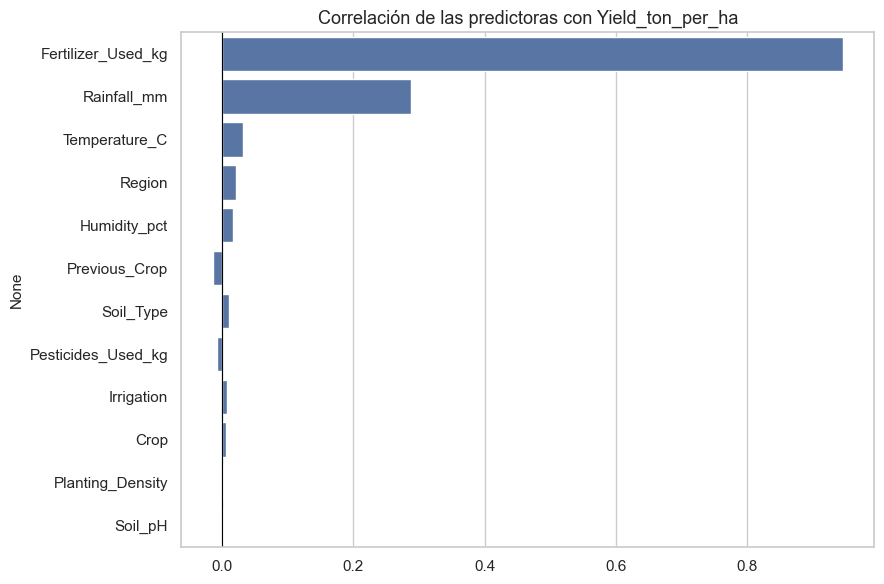

In [34]:
preprocesador_seleccion = crear_preprocesador(X.columns)
X_seleccion = preprocesador_seleccion.fit_transform(X_desarrollo)
nombres_transformados = preprocesador_seleccion.get_feature_names_out()

escalador_seleccion = StandardScaler()
X_seleccion_escalado = escalador_seleccion.fit_transform(X_seleccion)

correlaciones = pd.Series(
    [np.corrcoef(X_seleccion_escalado[:, i], y_desarrollo)[0, 1]
     for i in range(X_seleccion_escalado.shape[1])],
    index=[nombre.split("__", 1)[1] for nombre in nombres_transformados],
    name="Correlación"
).sort_values(key=abs, ascending=False)

display(correlaciones.to_frame().round(4))
plt.figure(figsize=(9, 6))
sns.barplot(x=correlaciones.values, y=correlaciones.index, color="#4C72B0")
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Correlación de las predictoras con {target}")
plt.tight_layout()
plt.show()

In [35]:
predictor_corr = pd.DataFrame(
    X_seleccion_escalado,
    columns=[nombre.split("__", 1)[1] for nombre in nombres_transformados]
).corr().abs()
upper_mask = np.triu(np.ones(predictor_corr.shape), k=1).astype(bool)

high_corr_pairs = (
    predictor_corr.where(upper_mask)
    .stack()
    .sort_values(ascending=False)
)
display(
    high_corr_pairs[high_corr_pairs > 0.80]
    .to_frame("Correlación absoluta")
    .round(4)
)

,,Correlación absoluta


`Fertilizer_Used_kg` presenta la mayor correlación positiva y `Rainfall_mm` ocupa el segundo lugar. Las demás asociaciones son débiles. Pearson no detecta relaciones no lineales y los resultados categóricos dependen del orden artificial, por lo que se complementa con RFE y árboles.

### Recursive Feature Elimination (RFE)

Se solicitan seis características. Ridge es compatible con RFE porque expone sus coeficientes mediante `coef_` y la regularización reduce inestabilidad.

In [36]:
rfe = RFE(
    estimator=Ridge(alpha=1.0),
    n_features_to_select=6,
    step=1
)
rfe.fit(X_seleccion_escalado, y_desarrollo)

nombres_originales_transformados = [
    nombre.split("__", 1)[1] for nombre in nombres_transformados
]
tabla_rfe = pd.DataFrame({
    "Característica": nombres_originales_transformados,
    "Ranking RFE": rfe.ranking_,
    "Seleccionada RFE": rfe.support_
}).sort_values(["Ranking RFE", "Característica"])

display(tabla_rfe)

,Característica,Ranking RFE,Seleccionada RFE
4,Fertilizer_Used_kg,1,True
3,Humidity_pct,1,True
11,Previous_Crop,1,True
1,Rainfall_mm,1,True
8,Region,1,True
2,Temperature_C,1,True
6,Planting_Density,2,False
10,Irrigation,3,False
7,Crop,4,False
9,Soil_Type,5,False


RFE selecciona fertilizante, lluvia, temperatura, humedad, región y cultivo previo. Las demás variables se descartan porque sus coeficientes aportan menos al ajuste lineal regularizado.

### Importancia mediante árboles

Se utiliza ExtraTreesRegressor, capaz de representar relaciones no lineales y publicar importancia mediante `feature_importances_`.

,Característica,Importancia,Ranking_árbol
0,Fertilizer_Used_kg,0.90013,1
1,Rainfall_mm,0.08453,2
2,Temperature_C,0.00235,3
3,Planting_Density,0.00150,4
4,Crop,0.00149,5
5,Previous_Crop,0.00147,6
6,Humidity_pct,0.00146,7
7,Region,0.00145,8
8,Irrigation,0.00144,9
9,Pesticides_Used_kg,0.00143,10


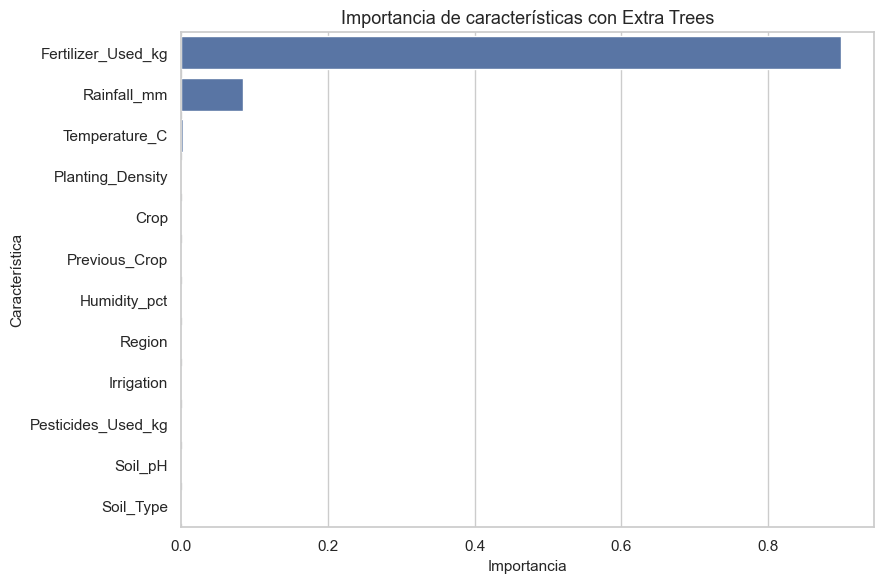

In [37]:
tree_selector = ExtraTreesRegressor(
    n_estimators=250,
    min_samples_leaf=2,
    random_state=SEMILLA,
    n_jobs=-1
)
tree_selector.fit(X_seleccion_escalado, y_desarrollo)

tree_table = pd.DataFrame({
    "Característica": nombres_originales_transformados,
    "Importancia": tree_selector.feature_importances_
}).sort_values("Importancia", ascending=False, ignore_index=True)
tree_table["Ranking_árbol"] = np.arange(1, len(tree_table) + 1)
display(tree_table.round(5))

plt.figure(figsize=(9, 6))
sns.barplot(data=tree_table, x="Importancia", y="Característica", color="#4C72B0")
plt.title("Importancia de características con Extra Trees")
plt.tight_layout()
plt.show()

El árbol concentra la importancia en fertilizante y lluvia. Las demás variables tienen aportes secundarios. A diferencia de la correlación y RFE, el árbol puede representar interacciones, aunque los cortes sobre códigos ordinales siguen condicionados por el orden artificial.

### Comparación y selección final

In [38]:
detalle_seleccion = pd.DataFrame({
    "Característica": nombres_originales_transformados,
    "Correlación": [correlaciones[n] for n in nombres_originales_transformados],
    "Correlación_abs": [abs(correlaciones[n]) for n in nombres_originales_transformados],
    "Ranking_RFE": rfe.ranking_,
    "Seleccionada_RFE": rfe.support_,
    "Importancia_árbol": tree_selector.feature_importances_
})

detalle_seleccion["Rank_corr"] = detalle_seleccion["Correlación_abs"].rank(ascending=False)
detalle_seleccion["Rank_RFE"] = detalle_seleccion["Ranking_RFE"].rank(ascending=True)
detalle_seleccion["Rank_árbol"] = detalle_seleccion["Importancia_árbol"].rank(ascending=False)
detalle_seleccion["Puntuación"] = detalle_seleccion[["Rank_corr", "Rank_RFE", "Rank_árbol"]].sum(axis=1)

caracteristicas_seleccionadas = (
    detalle_seleccion.sort_values(["Puntuación", "Rank_árbol"])
    .head(6)["Característica"].tolist()
)
caracteristicas_seleccionadas

['Fertilizer_Used_kg',
 'Rainfall_mm',
 'Temperature_C',
 'Previous_Crop',
 'Humidity_pct',
 'Region']

In [39]:
comparison = detalle_seleccion.copy()
comparison["Decisión"] = np.where(
    comparison["Característica"].isin(caracteristicas_seleccionadas),
    "Incluir",
    "Excluir"
)
comparison = comparison.sort_values(["Puntuación", "Rank_árbol"])
display(comparison.round(5))

,Característica,Correlación,Correlación_abs,Ranking_RFE,Seleccionada_RFE,Importancia_árbol,Rank_corr,Rank_RFE,Rank_árbol,Puntuación,Decisión
4,Fertilizer_Used_kg,0.94576,0.94576,1,True,0.90013,1.0,3.5,1.0,5.5,Incluir
1,Rainfall_mm,0.28720,0.28720,1,True,0.08453,2.0,3.5,2.0,7.5,Incluir
2,Temperature_C,0.03202,0.03202,1,True,0.00235,3.0,3.5,3.0,9.5,Incluir
11,Previous_Crop,-0.01438,0.01438,1,True,0.00147,6.0,3.5,6.0,15.5,Incluir
3,Humidity_pct,0.01695,0.01695,1,True,0.00146,5.0,3.5,7.0,15.5,Incluir
8,Region,0.02024,0.02024,1,True,0.00145,4.0,3.5,8.0,15.5,Incluir
6,Planting_Density,0.00110,0.00110,2,False,0.00150,11.0,7.0,4.0,22.0,Excluir
7,Crop,0.00508,0.00508,4,False,0.00149,10.0,9.0,5.0,24.0,Excluir
10,Irrigation,0.00782,0.00782,3,False,0.00144,9.0,8.0,9.0,26.0,Excluir
9,Soil_Type,0.01036,0.01036,5,False,0.00133,7.0,10.0,12.0,29.0,Excluir


Los tres métodos se comparan mediante una suma de rankings. Se seleccionan `Fertilizer_Used_kg`, `Rainfall_mm`, `Temperature_C`, `Previous_Crop`, `Humidity_pct` y `Region`. Fertilizante y lluvia coinciden claramente en correlación y árboles; RFE incorpora variables con efectos lineales menores. Las restantes presentan menor evidencia conjunta.

## Escenario 2: Análisis de Componentes Principales (PCA)

PCA se aplica después de imputar, convertir las categorías con OrdinalEncoder y estandarizar las 12 predictoras. Se conserva al menos 90% de la varianza; usar 95% conservaría todos los componentes y no reduciría la dimensión.

,Componente,Varianza_explicada,Varianza_acumulada
0,1,0.08786,0.08786
1,2,0.08749,0.17535
2,3,0.08688,0.26223
3,4,0.08459,0.34681
4,5,0.08448,0.43130
5,6,0.08342,0.51471
6,7,0.08314,0.59785
7,8,0.08241,0.68026
8,9,0.08113,0.76139
9,10,0.08068,0.84207


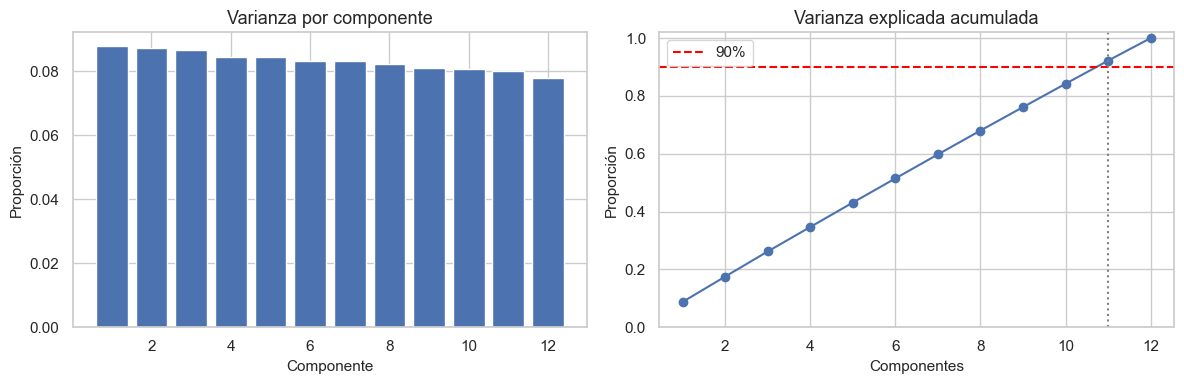

In [40]:
pca_analysis_pipeline = Pipeline([
    ("preprocesamiento", crear_preprocesador(X.columns)),
    ("escalador", StandardScaler()),
    ("pca", PCA())
])
pca_analysis_pipeline.fit(X_desarrollo)

pca_analysis = pca_analysis_pipeline.named_steps["pca"]
explained = pca_analysis.explained_variance_ratio_
explained_cumulative = np.cumsum(explained)
n_components_90 = int(np.argmax(explained_cumulative >= 0.90) + 1)

pca_table = pd.DataFrame({
    "Componente": np.arange(1, len(explained) + 1),
    "Varianza_explicada": explained,
    "Varianza_acumulada": explained_cumulative
})
display(pca_table.round(5))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(pca_table["Componente"], pca_table["Varianza_explicada"])
axes[0].set(title="Varianza por componente", xlabel="Componente", ylabel="Proporción")
axes[1].plot(pca_table["Componente"], pca_table["Varianza_acumulada"], marker="o")
axes[1].axhline(0.90, color="red", linestyle="--", label="90%")
axes[1].axvline(n_components_90, color="gray", linestyle=":")
axes[1].set(title="Varianza explicada acumulada", xlabel="Componentes", ylabel="Proporción")
axes[1].set_ylim(0, 1.02)
axes[1].legend()
plt.tight_layout()
plt.show()

In [41]:
pca_pipeline = Pipeline([
    ("preprocesamiento", crear_preprocesador(X.columns)),
    ("escalador", StandardScaler()),
    ("pca", PCA(n_components=0.90))
])

X_pca_preview = pca_pipeline.fit_transform(X_desarrollo)
retained_variance = pca_pipeline.named_steps["pca"].explained_variance_ratio_.sum()

resumen_pca = pd.DataFrame({
    "Variables antes": [X.shape[1]],
    "Componentes generados": [X.shape[1]],
    "Componentes conservados": [X_pca_preview.shape[1]],
    "Varianza conservada": [retained_variance],
    "Reducción porcentual": [100 * (1 - X_pca_preview.shape[1] / X.shape[1])]
})
display(resumen_pca.round(4))

,Variables antes,Componentes generados,Componentes conservados,Varianza conservada,Reducción porcentual
0,12,12,11,0.9221,8.3333


Se conservan 11 componentes, aproximadamente 92.21% de la varianza y una reducción de 8.33%. La reducción es pequeña porque OrdinalEncoder ya conserva una sola columna por variable. PCA reduce interpretación y puede descartar información predictiva de baja varianza.

# Modelado

## Selección de modelos

Se seleccionan dos algoritmos de regresión y una red neuronal. Los tres se utilizan en ambos escenarios.

### Ridge

In [42]:
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


### Extra Trees Regressor

In [43]:
modelo_extra_trees = ExtraTreesRegressor(
    n_estimators=250,
    min_samples_leaf=2,
    random_state=SEMILLA,
    n_jobs=1
)
modelo_extra_trees

,n_estimators,250
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


### MLP Regressor

In [44]:
modelo_mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=SEMILLA
)
modelo_mlp

,loss,'squared_error'
,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


# Evaluación y comparación de los seis experimentos

## Validación cruzada

Se utilizan las mismas siete particiones, semilla y métricas. Todo el preprocesamiento se ajusta dentro de cada fold.

In [45]:
kfold = KFold(n_splits=7, shuffle=True, random_state=SEMILLA)
metricas = {"r2": "r2", "mae": "neg_mean_absolute_error"}

## Escenario 1: características seleccionadas

### Ridge con características seleccionadas

In [46]:
pipeline_ridge_seleccionadas = Pipeline([
    ("preprocesamiento", crear_preprocesador(caracteristicas_seleccionadas)),
    ("escalador", StandardScaler()),
    ("modelo", clone(modelo_ridge))
])
resultado_ridge_seleccionadas = cross_validate(
    pipeline_ridge_seleccionadas, X_desarrollo, y_desarrollo,
    cv=kfold, scoring=metricas, n_jobs=1, return_train_score=True
)
r2_ridge_seleccionadas = resultado_ridge_seleccionadas["test_r2"]
mae_ridge_seleccionadas = -resultado_ridge_seleccionadas["test_mae"]

### Extra Trees con características seleccionadas

In [47]:
pipeline_extra_trees_seleccionadas = Pipeline([
    ("preprocesamiento", crear_preprocesador(caracteristicas_seleccionadas)),
    ("escalador", StandardScaler()),
    ("modelo", clone(modelo_extra_trees))
])
resultado_extra_trees_seleccionadas = cross_validate(
    pipeline_extra_trees_seleccionadas, X_desarrollo, y_desarrollo,
    cv=kfold, scoring=metricas, n_jobs=1, return_train_score=True
)
r2_extra_trees_seleccionadas = resultado_extra_trees_seleccionadas["test_r2"]
mae_extra_trees_seleccionadas = -resultado_extra_trees_seleccionadas["test_mae"]

### MLP con características seleccionadas

In [48]:
pipeline_mlp_seleccionadas = Pipeline([
    ("preprocesamiento", crear_preprocesador(caracteristicas_seleccionadas)),
    ("escalador", StandardScaler()),
    ("modelo", clone(modelo_mlp))
])
resultado_mlp_seleccionadas = cross_validate(
    pipeline_mlp_seleccionadas, X_desarrollo, y_desarrollo,
    cv=kfold, scoring=metricas, n_jobs=1, return_train_score=True
)
r2_mlp_seleccionadas = resultado_mlp_seleccionadas["test_r2"]
mae_mlp_seleccionadas = -resultado_mlp_seleccionadas["test_mae"]

### Resultados con características seleccionadas

In [49]:
def fila_resultado(nombre, resultado):
    r2 = resultado["test_r2"]
    mae = -resultado["test_mae"]
    return [
        nombre, r2.mean(), r2.std(ddof=0), r2.var(ddof=0),
        mae.mean(), mae.std(ddof=0), mae.var(ddof=0),
        resultado["train_r2"].mean(), resultado["fit_time"].mean()
    ]

columnas_resultado = [
    "Modelo", "R2 medio", "Desv. est. R2", "Varianza R2",
    "MAE medio", "Desv. est. MAE", "Varianza MAE",
    "R2 entrenamiento", "Tiempo medio"
]
tabla_seleccionadas = pd.DataFrame([
    fila_resultado("Ridge", resultado_ridge_seleccionadas),
    fila_resultado("Extra Trees", resultado_extra_trees_seleccionadas),
    fila_resultado("MLP", resultado_mlp_seleccionadas)
], columns=columnas_resultado)
display(tabla_seleccionadas.round(5))

,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE,R2 entrenamiento,Tiempo medio
0,Ridge,0.97856,0.00167,0.0,4.28136,0.08951,0.00801,0.97867,0.01071
1,Extra Trees,0.97562,0.00183,0.0,4.56268,0.08854,0.00784,0.99690,1.68599
2,MLP,0.97748,0.00165,0.0,4.39180,0.09424,0.00888,0.97810,1.63114


## Escenario 2: PCA

### Ridge con PCA

In [50]:
pipeline_ridge_pca = Pipeline([
    ("preprocesamiento", crear_preprocesador(X.columns)),
    ("escalador", StandardScaler()),
    ("pca", PCA(n_components=0.90)),
    ("modelo", clone(modelo_ridge))
])
resultado_ridge_pca = cross_validate(
    pipeline_ridge_pca, X_desarrollo, y_desarrollo,
    cv=kfold, scoring=metricas, n_jobs=1, return_train_score=True
)
r2_ridge_pca = resultado_ridge_pca["test_r2"]
mae_ridge_pca = -resultado_ridge_pca["test_mae"]

### Extra Trees con PCA

In [51]:
pipeline_extra_trees_pca = Pipeline([
    ("preprocesamiento", crear_preprocesador(X.columns)),
    ("escalador", StandardScaler()),
    ("pca", PCA(n_components=0.90)),
    ("modelo", clone(modelo_extra_trees))
])
resultado_extra_trees_pca = cross_validate(
    pipeline_extra_trees_pca, X_desarrollo, y_desarrollo,
    cv=kfold, scoring=metricas, n_jobs=1, return_train_score=True
)
r2_extra_trees_pca = resultado_extra_trees_pca["test_r2"]
mae_extra_trees_pca = -resultado_extra_trees_pca["test_mae"]

### MLP con PCA

In [52]:
pipeline_mlp_pca = Pipeline([
    ("preprocesamiento", crear_preprocesador(X.columns)),
    ("escalador", StandardScaler()),
    ("pca", PCA(n_components=0.90)),
    ("modelo", clone(modelo_mlp))
])
resultado_mlp_pca = cross_validate(
    pipeline_mlp_pca, X_desarrollo, y_desarrollo,
    cv=kfold, scoring=metricas, n_jobs=1, return_train_score=True
)
r2_mlp_pca = resultado_mlp_pca["test_r2"]
mae_mlp_pca = -resultado_mlp_pca["test_mae"]

### Resultados con PCA

In [53]:
tabla_pca_resultados = pd.DataFrame([
    fila_resultado("Ridge", resultado_ridge_pca),
    fila_resultado("Extra Trees", resultado_extra_trees_pca),
    fila_resultado("MLP", resultado_mlp_pca)
], columns=columnas_resultado)
display(tabla_pca_resultados.round(5))

,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE,R2 entrenamiento,Tiempo medio
0,Ridge,0.89156,0.03335,0.00111,9.93480,1.53413,2.35357,0.89645,0.01595
1,Extra Trees,0.83766,0.02836,0.00080,12.35398,1.19660,1.43186,0.99188,2.49964
2,MLP,0.92356,0.02037,0.00041,8.03307,0.96503,0.93128,0.93633,3.73209


## Comparación general

In [54]:
tabla_general = pd.concat([
    tabla_seleccionadas.assign(Escenario="Características seleccionadas"),
    tabla_pca_resultados.assign(Escenario="PCA")
], ignore_index=True)

tabla_general = tabla_general[[
    "Escenario", "Modelo", "R2 medio", "Desv. est. R2",
    "Varianza R2", "MAE medio", "Desv. est. MAE", "Varianza MAE",
    "R2 entrenamiento", "Tiempo medio"
]]
display(tabla_general.round(5))

,Escenario,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE,R2 entrenamiento,Tiempo medio
0,Características seleccionadas,Ridge,0.97856,0.00167,0.00000,4.28136,0.08951,0.00801,0.97867,0.01071
1,Características seleccionadas,Extra Trees,0.97562,0.00183,0.00000,4.56268,0.08854,0.00784,0.99690,1.68599
2,Características seleccionadas,MLP,0.97748,0.00165,0.00000,4.39180,0.09424,0.00888,0.97810,1.63114
3,PCA,Ridge,0.89156,0.03335,0.00111,9.93480,1.53413,2.35357,0.89645,0.01595
4,PCA,Extra Trees,0.83766,0.02836,0.00080,12.35398,1.19660,1.43186,0.99188,2.49964
5,PCA,MLP,0.92356,0.02037,0.00041,8.03307,0.96503,0.93128,0.93633,3.73209


## Boxplot de comparación

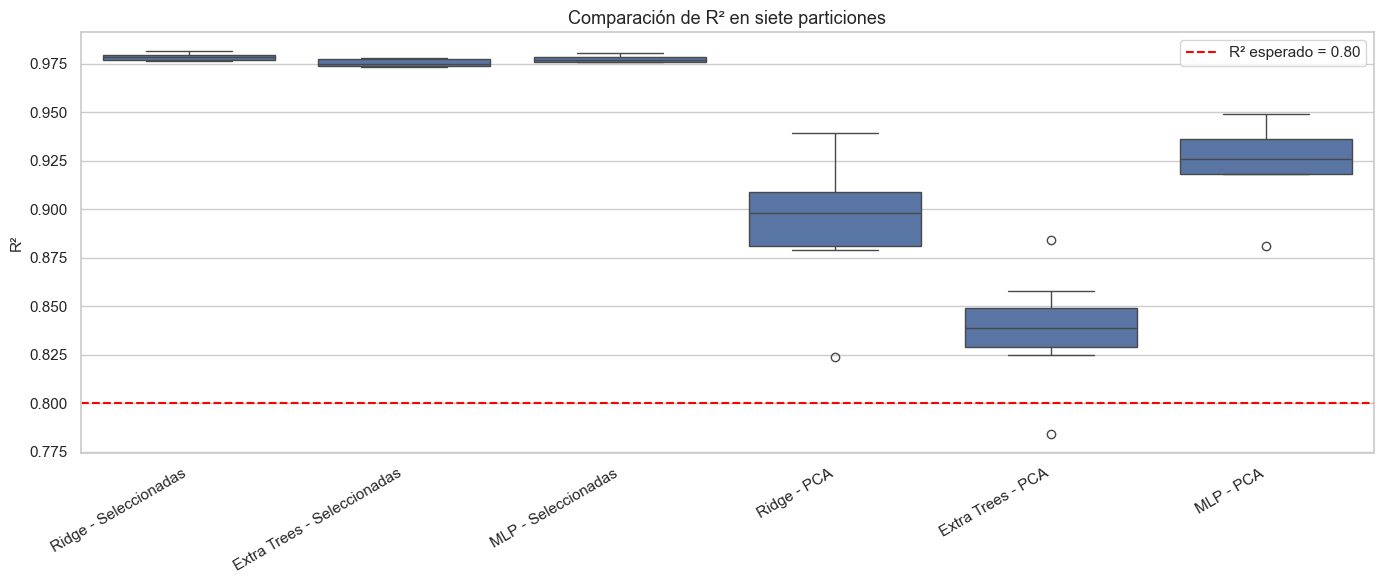

In [55]:
r2_boxplot = pd.DataFrame({
    "Ridge - Seleccionadas": r2_ridge_seleccionadas,
    "Extra Trees - Seleccionadas": r2_extra_trees_seleccionadas,
    "MLP - Seleccionadas": r2_mlp_seleccionadas,
    "Ridge - PCA": r2_ridge_pca,
    "Extra Trees - PCA": r2_extra_trees_pca,
    "MLP - PCA": r2_mlp_pca
})

plt.figure(figsize=(14, 6))
sns.boxplot(data=r2_boxplot, color="#4C72B0")
plt.axhline(0.80, color="red", linestyle="--", label="R² esperado = 0.80")
plt.ylabel("R²")
plt.xticks(rotation=30, ha="right")
plt.title("Comparación de R² en siete particiones")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
estadisticas_boxplot = pd.DataFrame([
    [col, r2_boxplot[col].median(), r2_boxplot[col].std(ddof=0),
     r2_boxplot[col].quantile(0.25), r2_boxplot[col].quantile(0.75),
     r2_boxplot[col].min(), r2_boxplot[col].max()]
    for col in r2_boxplot.columns
], columns=["Experimento", "Mediana", "Desv. estándar", "Q1", "Q3", "Mínimo", "Máximo"])
estadisticas_boxplot["IQR"] = estadisticas_boxplot["Q3"] - estadisticas_boxplot["Q1"]
display(estadisticas_boxplot.round(5))

,Experimento,Mediana,Desv. estándar,Q1,Q3,Mínimo,Máximo,IQR
0,Ridge - Seleccionadas,0.97857,0.00167,0.97701,0.97967,0.97658,0.98140,0.00266
1,Extra Trees - Seleccionadas,0.97506,0.00183,0.97406,0.97744,0.97325,0.97804,0.00337
2,MLP - Seleccionadas,0.97705,0.00165,0.97596,0.97854,0.97579,0.98050,0.00258
3,Ridge - PCA,0.89822,0.03335,0.88089,0.90895,0.82370,0.93930,0.02806
4,Extra Trees - PCA,0.83898,0.02836,0.82893,0.84916,0.78423,0.88425,0.02023
5,MLP - PCA,0.92610,0.02037,0.91831,0.93604,0.88110,0.94900,0.01773


Ridge con características seleccionadas presenta la mediana más alta y una dispersión muy baja. Los tres modelos con selección son estables. PCA reduce el rendimiento y aumenta la dispersión, especialmente para Ridge y Extra Trees; MLP es el modelo que mejor tolera PCA. No se elige un máximo aislado, sino el comportamiento de las siete particiones.

## Selección del mejor modelo

In [57]:
mejor_seleccionadas = tabla_seleccionadas.sort_values(
    ["R2 medio", "MAE medio"], ascending=[False, True]
).head(1)
mejor_pca = tabla_pca_resultados.sort_values(
    ["R2 medio", "MAE medio"], ascending=[False, True]
).head(1)
mejor_general = tabla_general.sort_values(
    ["R2 medio", "MAE medio", "Desv. est. R2"],
    ascending=[False, True, True]
).head(1)

print("Mejor con características seleccionadas:")
display(mejor_seleccionadas.round(5))
print("Mejor con PCA:")
display(mejor_pca.round(5))
print("Mejor experimento general:")
display(mejor_general.round(5))

Mejor con características seleccionadas:


,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE,R2 entrenamiento,Tiempo medio
0,Ridge,0.97856,0.00167,0.0,4.28136,0.08951,0.00801,0.97867,0.01071


Mejor con PCA:


,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE,R2 entrenamiento,Tiempo medio
2,MLP,0.92356,0.02037,0.00041,8.03307,0.96503,0.93128,0.93633,3.73209


Mejor experimento general:


,Escenario,Modelo,R2 medio,Desv. est. R2,Varianza R2,MAE medio,Desv. est. MAE,Varianza MAE,R2 entrenamiento,Tiempo medio
0,Características seleccionadas,Ridge,0.97856,0.00167,0.0,4.28136,0.08951,0.00801,0.97867,0.01071


In [58]:
tiempos_entrenamiento = tabla_general[["Escenario", "Modelo", "Tiempo medio"]].copy()
display(tiempos_entrenamiento.round(5))

,Escenario,Modelo,Tiempo medio
0,Características seleccionadas,Ridge,0.01071
1,Características seleccionadas,Extra Trees,1.68599
2,Características seleccionadas,MLP,1.63114
3,PCA,Ridge,0.01595
4,PCA,Extra Trees,2.49964
5,PCA,MLP,3.73209


El mejor modelo con características seleccionadas es Ridge y el mejor con PCA es MLP. El mejor experimento general es Ridge con características seleccionadas: combina el R² medio más alto, el MAE más bajo, baja variabilidad, entrenamiento rápido y una brecha mínima entre entrenamiento y validación. PCA no mejora los resultados.

## Tabla detallada del mejor modelo

In [59]:
r2_mejor = r2_ridge_seleccionadas
mae_mejor = mae_ridge_seleccionadas

tabla_mejor_modelo = pd.DataFrame({
    "Partición": [1, 2, 3, 4, 5, 6, 7],
    "R2": r2_mejor,
    "MAE": mae_mejor
})
resumen_mejor = pd.DataFrame({
    "Partición": ["Media", "Desviación estándar", "Varianza"],
    "R2": [r2_mejor.mean(), r2_mejor.std(ddof=0), r2_mejor.var(ddof=0)],
    "MAE": [mae_mejor.mean(), mae_mejor.std(ddof=0), mae_mejor.var(ddof=0)]
})
display(pd.concat([tabla_mejor_modelo, resumen_mejor], ignore_index=True).round(6))

,Partición,R2,MAE
0,1,0.979366,4.238298
1,2,0.977231,4.326455
2,3,0.976585,4.374417
3,4,0.976785,4.387728
4,5,0.978573,4.302379
5,6,0.979968,4.229400
6,7,0.981398,4.110823
7,Media,0.978558,4.281357
8,Desviación estándar,0.001669,0.089512
9,Varianza,0.000003,0.008012


In [60]:
mejor_particion = int(np.argmax(r2_mejor) + 1)
peor_particion = int(np.argmin(r2_mejor) + 1)
diferencia_r2 = float(r2_mejor.max() - r2_mejor.min())

print("Mejor partición:", mejor_particion, "R² =", round(r2_mejor.max(), 5))
print("Peor partición:", peor_particion, "R² =", round(r2_mejor.min(), 5))
print("Diferencia:", round(diferencia_r2, 5))
print("Varianza:", round(r2_mejor.var(ddof=0), 7))

Mejor partición: 7 R² = 0.9814
Peor partición: 3 R² = 0.97658
Diferencia: 0.00481
Varianza: 2.8e-06


La diferencia entre la mejor y peor partición es pequeña y la varianza está muy por debajo de 0.01. La media es representativa y todos los folds superan 0.80, por lo que el resultado no depende de una sola división favorable.

# Evaluación final del mejor modelo

## División de entrenamiento y prueba

Se evalúa únicamente Ridge con las seis características finales, usando el 80% de desarrollo y el 20% protegido. El preprocesamiento conserva la misma configuración del experimento seleccionado.

In [61]:
pipeline_mejor_modelo = clone(pipeline_ridge_seleccionadas)
pipeline_mejor_modelo.fit(X_desarrollo, y_desarrollo)
y_pred = pipeline_mejor_modelo.predict(X_prueba_final)

r2_final = r2_score(y_prueba_final, y_pred)
mae_final = mean_absolute_error(y_prueba_final, y_pred)
residuos = y_prueba_final.to_numpy() - y_pred
error_absoluto = np.abs(residuos)

print("Registros de entrenamiento:", len(X_desarrollo))
print("Registros de prueba:", len(X_prueba_final))
print("R² final:", round(r2_final, 5))
print("MAE final:", round(mae_final, 5))

Registros de entrenamiento: 8000
Registros de prueba: 2000
R² final: 0.97806
MAE final: 4.38989


In [62]:
cuartil_bajo = y_prueba_final.quantile(0.25)
cuartil_alto = y_prueba_final.quantile(0.75)

mae_valores_bajos = error_absoluto[y_prueba_final <= cuartil_bajo].mean()
mae_valores_medios = error_absoluto[
    (y_prueba_final > cuartil_bajo) & (y_prueba_final < cuartil_alto)
].mean()
mae_valores_altos = error_absoluto[y_prueba_final >= cuartil_alto].mean()

tabla_error_rangos = pd.DataFrame({
    "Rango": ["Bajo", "Medio", "Alto"],
    "MAE": [mae_valores_bajos, mae_valores_medios, mae_valores_altos]
})
display(tabla_error_rangos.round(4))

,Rango,MAE
0,Bajo,4.4445
1,Medio,4.5140
2,Alto,4.0871


## Valores reales contra valores predichos

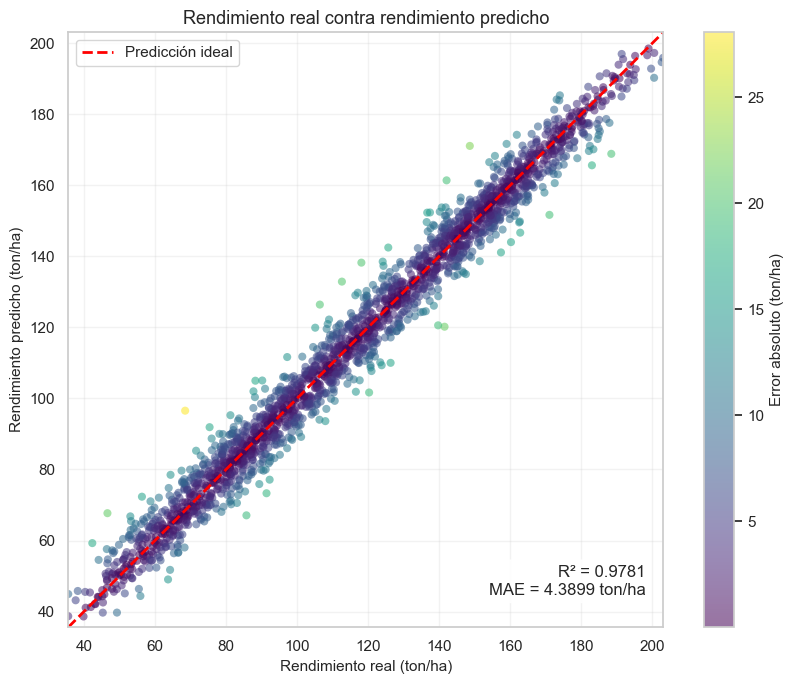

In [63]:
limite_minimo = min(y_prueba_final.min(), y_pred.min())
limite_maximo = max(y_prueba_final.max(), y_pred.max())

fig, ax = plt.subplots(figsize=(9, 7))
puntos = ax.scatter(
    y_prueba_final,
    y_pred,
    c=error_absoluto,
    cmap="viridis",
    alpha=0.55,
    s=34,
    edgecolors="none"
)
ax.plot(
    [limite_minimo, limite_maximo],
    [limite_minimo, limite_maximo],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Predicción ideal"
)
ax.set(
    title="Rendimiento real contra rendimiento predicho",
    xlabel="Rendimiento real (ton/ha)",
    ylabel="Rendimiento predicho (ton/ha)",
    xlim=(limite_minimo, limite_maximo),
    ylim=(limite_minimo, limite_maximo)
)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.25)
ax.legend(loc="upper left")
ax.text(
    0.97,
    0.05,
    f"R² = {r2_final:.4f}\nMAE = {mae_final:.4f} ton/ha",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9}
)
fig.colorbar(puntos, ax=ax, label="Error absoluto (ton/ha)")
plt.tight_layout()
plt.show()

La mayoría de los puntos se concentra cerca de la línea ideal, de acuerdo con el R² final cercano a 0.978. Los puntos sobre la línea representan subestimación y los situados debajo representan sobreestimación. La dispersión restante indica factores no explicados por las seis variables.

## Gráfica de residuos

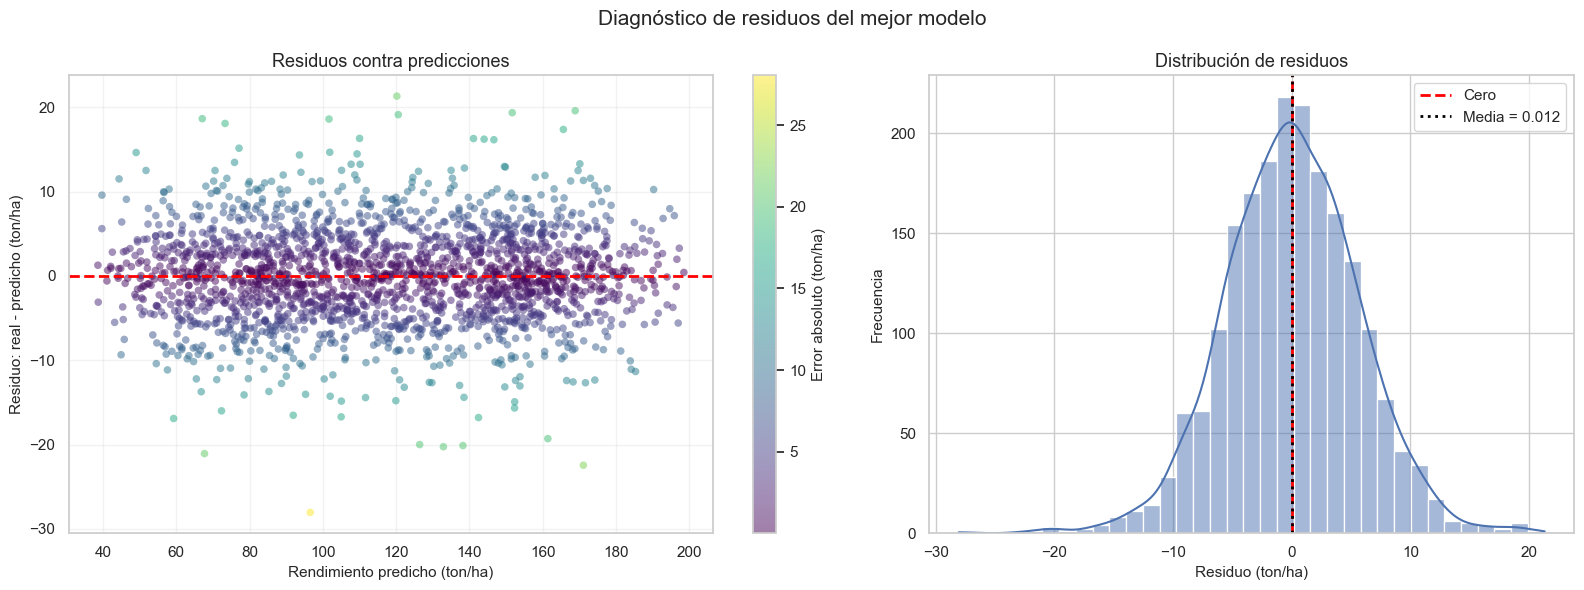

,Indicador,Valor
0,Media de residuos,0.01213
1,Desviación de residuos,5.62917
2,Error absoluto P95,10.93087
3,Correlación predicción-error absoluto,-0.02866


In [64]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.25, 1]}
)

puntos_residuos = axes[0].scatter(
    y_pred,
    residuos,
    c=error_absoluto,
    cmap="viridis",
    alpha=0.5,
    s=30,
    edgecolors="none"
)
axes[0].axhline(0, color="red", linestyle="--", linewidth=2)
axes[0].set(
    title="Residuos contra predicciones",
    xlabel="Rendimiento predicho (ton/ha)",
    ylabel="Residuo: real - predicho (ton/ha)"
)
axes[0].grid(alpha=0.25)
fig.colorbar(puntos_residuos, ax=axes[0], label="Error absoluto (ton/ha)")

sns.histplot(residuos, bins=35, kde=True, ax=axes[1], color="#4C72B0")
axes[1].axvline(0, color="red", linestyle="--", linewidth=2, label="Cero")
axes[1].axvline(
    residuos.mean(),
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Media = {residuos.mean():.3f}"
)
axes[1].set(
    title="Distribución de residuos",
    xlabel="Residuo (ton/ha)",
    ylabel="Frecuencia"
)
axes[1].legend()

plt.suptitle("Diagnóstico de residuos del mejor modelo", fontsize=15)
plt.tight_layout()
plt.show()

estadisticas_residuos = pd.DataFrame({
    "Indicador": [
        "Media de residuos",
        "Desviación de residuos",
        "Error absoluto P95",
        "Correlación predicción-error absoluto"
    ],
    "Valor": [
        residuos.mean(),
        residuos.std(ddof=0),
        np.quantile(error_absoluto, 0.95),
        np.corrcoef(y_pred, error_absoluto)[0, 1]
    ]
})
display(estadisticas_residuos.round(5))

Los residuos se concentran alrededor de cero y su media permite comprobar si existe sesgo global. La dispersión vertical representa el error que permanece sin explicar; los casos de mayor coloración corresponden a errores absolutos más altos. El histograma ayuda a detectar asimetría o colas extremas, mientras el percentil 95 resume un límite práctico para la mayoría de los errores.

# Entrenamiento y almacenamiento del modelo final

Ridge se vuelve a entrenar con todos los registros y se guarda junto con selección, imputación, codificación ordinal y escalado.

In [65]:
pipeline_final = clone(pipeline_ridge_seleccionadas)
pipeline_final.fit(X, y)

archivo_modelo = "pipeline_crop_yield_final.joblib"
joblib.dump(pipeline_final, archivo_modelo, compress=3)

print("Modelo entrenado con", len(X), "registros")
print("Archivo guardado:", archivo_modelo)

Modelo entrenado con 10000 registros
Archivo guardado: pipeline_crop_yield_final.joblib


## Comprobación del archivo guardado

In [66]:
pipeline_cargado = joblib.load(archivo_modelo)
prediccion_comprobacion = pipeline_cargado.predict(X.iloc[[0]])[0]

print("Predicción generada:", round(float(prediccion_comprobacion), 4))
print("Valor real:", round(float(y.iloc[0]), 4))
print("Encoder guardado:", type(
    pipeline_cargado.named_steps["preprocesamiento"]
    .named_transformers_["cat"].named_steps["ordinal"]
).__name__)

Predicción generada: 100.9602
Valor real: 101.48
Encoder guardado: OrdinalEncoder


# Conclusiones y reflexión crítica

El análisis mostró que el rendimiento está asociado principalmente con la cantidad de fertilizante y la lluvia, mientras las demás variables aportan ajustes menores. La lectura correcta de `None` fue importante para no confundir ausencia de riego o cultivo previo con datos faltantes. Los nulos generados para el ejercicio se trataron dentro de pipelines para evitar fuga de información.

Ridge con características seleccionadas ofreció el mejor equilibrio entre precisión, estabilidad y tiempo. PCA redujo poco la dimensión y perdió información útil para la predicción. OrdinalEncoder mantuvo una representación compacta, aunque su orden artificial limita la interpretación de las variables nominales.

El dataset es sintético y omite factores como variedades, enfermedades, temporalidad y condiciones locales. Por ello, el modelo no debe utilizarse como recomendación agronómica directa. Un estudio posterior debería incorporar datos reales de varias temporadas, validación geográfica y temporal, e intervalos de incertidumbre. En un entorno real, una predicción errónea podría afectar compras de insumos, almacenamiento y expectativas económicas; sus resultados deben apoyar, no sustituir, el criterio técnico.